In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [16]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [39]:
#data cleanind
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    float64
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    float64
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    float64
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(6), int64(8)
memory usage: 35.4 KB
None


In [13]:
df.drop_duplicates(inplace=True)
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [40]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.529594    0.682119    0.963576    0.351493    0.272550    0.149007   
std      0.188499    0.466426    1.032044    0.156653    0.108417    0.356686   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.395833    0.000000    0.000000    0.245283    0.194064    0.000000   
50%      0.552083    1.000000    1.000000    0.339623    0.261416    0.000000   
75%      0.666667    1.000000    2.000000    0.433962    0.339612    0.000000   
max      1.000000    1.000000    3.000000    0.716981    0.557934    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490    0.600099    0.327815    0.165777    1.397351    0.166391   
std      0.526027    0.1737

In [41]:
print(df.head())

        age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.479167    1   0  0.292453  0.196347    0        1  0.740458      0   
1  0.500000    1   0  0.433962  0.175799    1        0  0.641221      1   
2  0.854167    1   0  0.481132  0.109589    0        1  0.412214      1   
3  0.666667    1   0  0.509434  0.175799    0        1  0.687023      0   
4  0.687500    0   0  0.415094  0.383562    1        1  0.267176      0   

    oldpeak  slope     ca  thal  target  
0  0.161290      2  0.500     3       0  
1  0.500000      0  0.000     3       0  
2  0.419355      0  0.000     3       0  
3  0.000000      2  0.250     3       0  
4  0.306452      1  0.625     2       0  


In [6]:
#data integration
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
df.fbs.unique()

array([0, 1])

In [8]:
subSet1 = df[['age','cp','chol','thalach']]
subSet2 = df[['exang','slope','target']]

In [9]:
merged_df = subSet1.merge(right=subSet2,how='cross')
merged_df.head()

,age,cp,chol,thalach,exang,slope,target
0,52,0,212,168,0,2,0
1,52,0,212,168,1,0,0
2,52,0,212,168,1,0,0
3,52,0,212,168,0,2,0
4,52,0,212,168,0,1,0


In [18]:
#data transformation
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()


cat_cols = ['sex', 'cp', 'fbs', 'restecg',
            'exang', 'slope', 'thal']

for col in cat_cols:

    df[col] = encoder.fit_transform(df[col])


print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [19]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['age', 'trestbps', 'chol',
            'thalach', 'oldpeak', 'ca']



scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

print(df.head())

        age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.479167    1   0  0.292453  0.196347    0        1  0.740458      0   
1  0.500000    1   0  0.433962  0.175799    1        0  0.641221      1   
2  0.854167    1   0  0.481132  0.109589    0        1  0.412214      1   
3  0.666667    1   0  0.509434  0.175799    0        1  0.687023      0   
4  0.687500    0   0  0.415094  0.383562    1        1  0.267176      0   

    oldpeak  slope    ca  thal  target  
0  0.161290      2  0.50     3       0  
1  0.500000      0  0.00     3       0  
2  0.419355      0  0.00     3       0  
3  0.000000      2  0.25     3       0  
4  0.306452      1  0.75     2       0  


In [20]:
# error corrrecting
def remove_outliers(col):

    Q1 = col.quantile(0.25)

    Q3 = col.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    return col.clip(lower=lower, upper=upper)

In [22]:
outlier_cols = ['age', 'trestbps', 'chol',
                'thalach', 'oldpeak', 'ca']



for col in outlier_cols:

    df[col] = remove_outliers(df[col])



print(df.head())

        age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.479167    1   0  0.292453  0.196347    0        1  0.740458      0   
1  0.500000    1   0  0.433962  0.175799    1        0  0.641221      1   
2  0.854167    1   0  0.481132  0.109589    0        1  0.412214      1   
3  0.666667    1   0  0.509434  0.175799    0        1  0.687023      0   
4  0.687500    0   0  0.415094  0.383562    1        1  0.267176      0   

    oldpeak  slope     ca  thal  target  
0  0.161290      2  0.500     3       0  
1  0.500000      0  0.000     3       0  
2  0.419355      0  0.000     3       0  
3  0.000000      2  0.250     3       0  
4  0.306452      1  0.625     2       0  


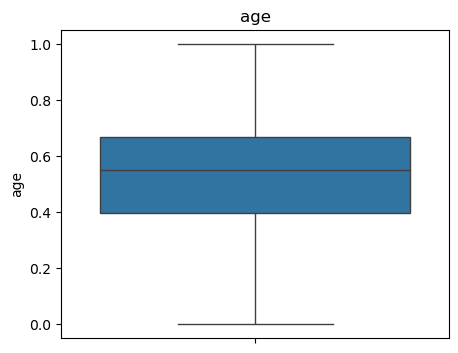

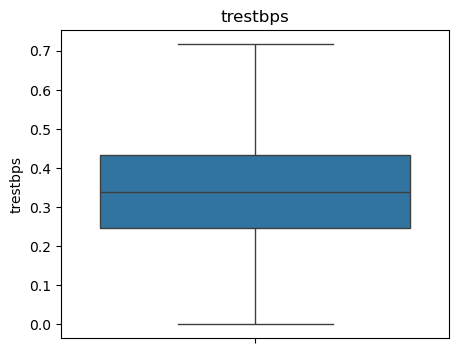

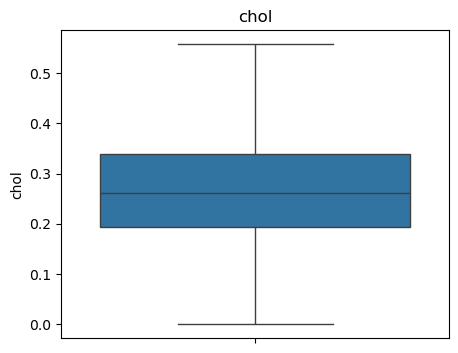

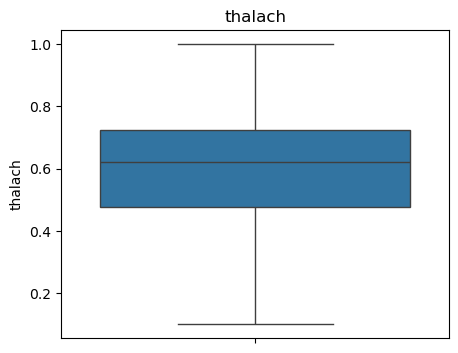

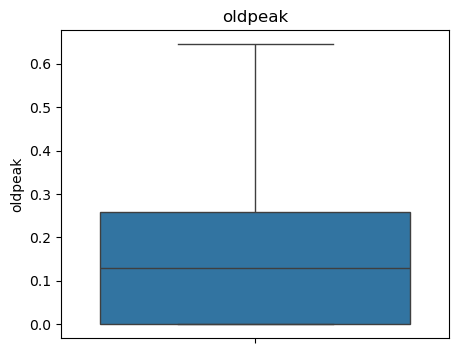

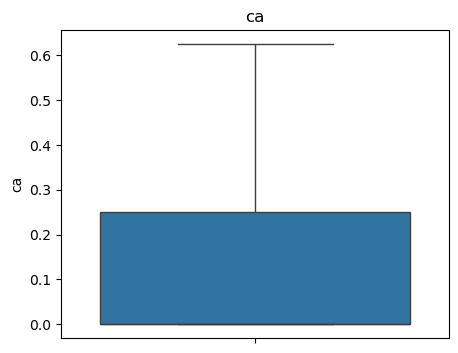

In [23]:
for col in outlier_cols:

    plt.figure(figsize=(5,4))

    sns.boxplot(y=df[col])

    plt.title(col)

    plt.show()

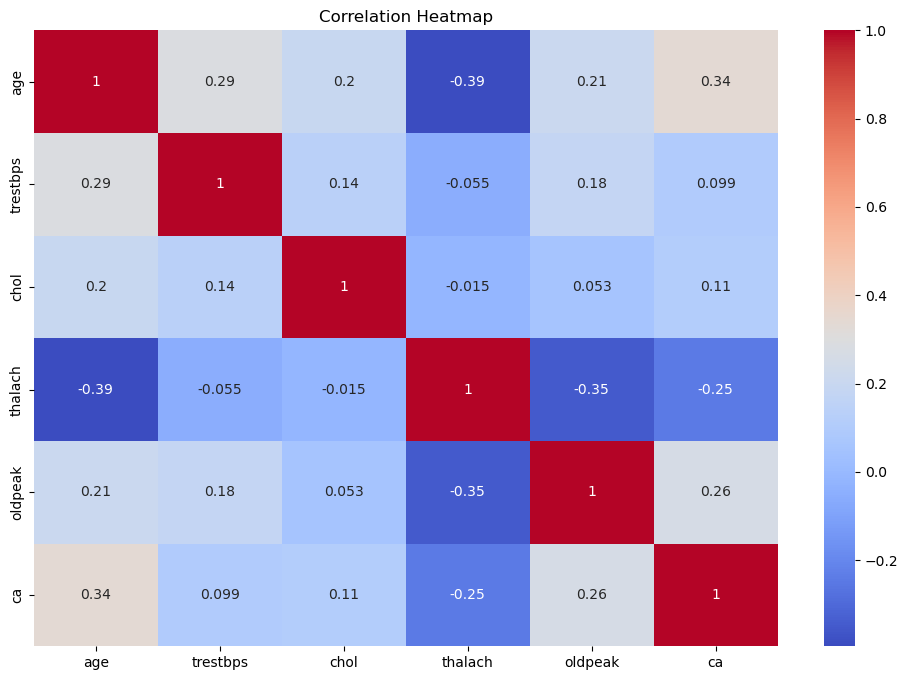

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [29]:


X = df[['age', 'cp', 'chol',
        'thalach', 'exang',
        'oldpeak', 'slope', 'ca']]

#
y = df['target']


print(X.shape)

print(y.shape)

(302, 8)
(302,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print(X_train.shape)

print(X_test.shape)

(241, 8)
(61, 8)


In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)


Accuracy : 0.8360655737704918


In [37]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[24  8]
 [ 2 27]]


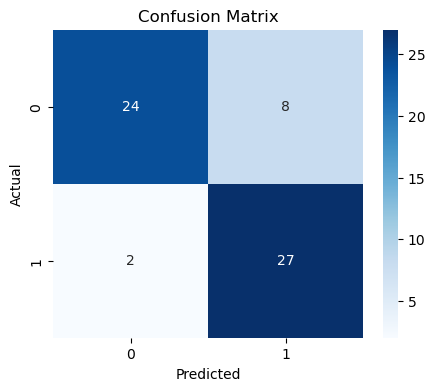

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()